In [1]:
import json
import pandas as pd

In [2]:

with open('data/dataset.json') as file:
    data = json.loads(file.read())

In [3]:
df = pd.DataFrame(data)

In [4]:
df.head()

,author,kind,genre,title,text
0,Adam_Mickiewicz,Dramat,Dramat_romantyczny,"Dziady, część II",DZIADY. Jest to nazwisko uroczystości obchodzo...
1,Adam_Mickiewicz,Dramat,Dramat_romantyczny,"Dziady, część II","Mów, czego trzeba dla duszy,\nAby się dostać d..."
2,Adam_Mickiewicz,Dramat,Dramat_romantyczny,"Dziady, część III","spółuczniom, spółwięźniom, spółwygnańcom\nza m..."
3,Adam_Mickiewicz,Dramat,Dramat_romantyczny,"Dziady, część III","I skądże się tu wziąłeś, Żegoto kochany? Kiedy..."
4,Adam_Mickiewicz,Dramat,Dramat_romantyczny,"Dziady, część III",Spojrzałem w kościół pusty i rękę kapłańską\nW...


In [5]:
df.value_counts(subset=['author', 'kind'])

author             kind  
Juliusz_Słowacki   Dramat    71
Zygmunt_Krasiński  Epika     70
Adam_Mickiewicz    Epika     50
                   Dramat    21
Zygmunt_Krasiński  Dramat     1
Name: count, dtype: int64

In [6]:
df['author'].value_counts()

author
Adam_Mickiewicz      71
Juliusz_Słowacki     71
Zygmunt_Krasiński    71
Name: count, dtype: int64

### Ważne: brakuje kombinacji SłowackixDramat

# Pytanie 1

In [7]:
from pytania_badawcze.pytanie_1.evaluation import evaluate_no_genre_control, evaluate_with_genre_control, statistical_tests
from pytania_badawcze.pytanie_1.preprocessig import build_chunk_dataset
from pytania_badawcze.pytanie_1.plots import print_report, plot_all
from sklearn.feature_extraction.text import TfidfVectorizer


Budowanie zbioru...
  Chunki: 850 fragmentów z 18 tytułów

Ewaluacja: word_unigram
  Wariant: bez kontroli gatunku...
  Wariant: z kontrolą gatunku...

WYNIKI EKSPERYMENTU

Wektoryzacja: word_unigram
  Wariant BEZ kontroli gatunku:
    F1-macro  = 0.3034  ± 0.1635  (n_foldów=5)
    Accuracy  = 0.4697  ± 0.2707
  Wariant Z kontrolą gatunku:
    F1-macro  = 0.4186  ± 0.3326  (n_obserwacji=10)
    Accuracy  = 0.5804  ± 0.3635

  Różnica F1 (z kontrolą − bez) = +0.1152
  Welch t-test:   t = -0.836,  p = 0.4182
  Mann-Whitney U: U = 22.0,  p = 0.7593
  Istotność statystyczna: NIE (p ≥ 0.05)

  F1 per gatunek (wariant z kontrolą):
    Dramat  : F1 = 0.4428 ± 0.3288  [Mickiewicz, Słowacki, Krasiński]  5-fold
    Epika   : F1 = 0.3944 ± 0.3346  [Mickiewicz, Krasiński]  5-fold


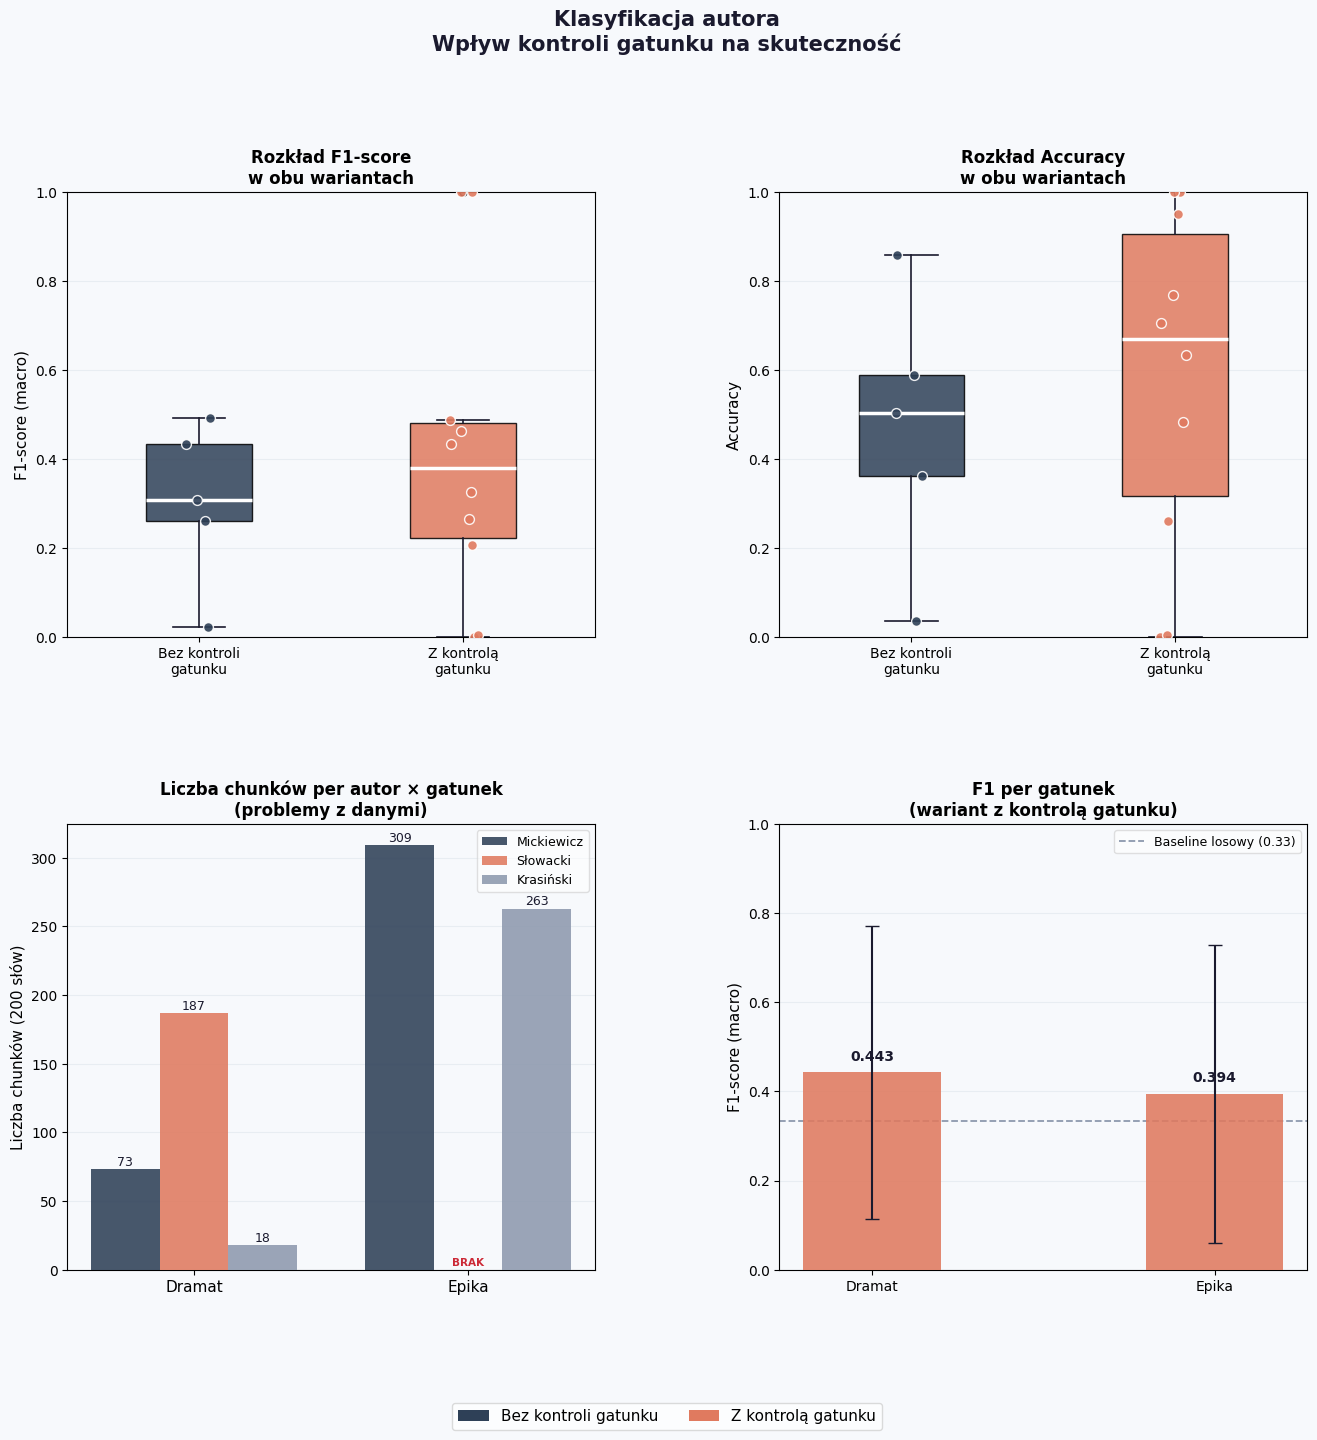

✓ Wykres zapisany: wyniki_autorstwo.png


In [8]:
print("Budowanie zbioru...")
df_chunks = build_chunk_dataset(df)
print(f"  Chunki: {len(df_chunks)} fragmentów z {df['title'].nunique()} tytułów")


vectorizer_cfg = {
    "word_unigram": TfidfVectorizer(analyzer="word", ngram_range=(1, 1)),
}

results = []

for name, vec in vectorizer_cfg.items():
    print(f"\nEwaluacja: {name}")

    print("  Wariant: bez kontroli gatunku...")
    f1_no, acc_no = evaluate_no_genre_control(df_chunks, vec)

    print("  Wariant: z kontrolą gatunku...")
    vec2 = TfidfVectorizer(analyzer="word", ngram_range=(1, 1))
    f1_gen, acc_gen, per_genre = evaluate_with_genre_control(df_chunks, vec2)

    stats = statistical_tests(f1_no, f1_gen)

    results.append({
        "vectorizer": name,
        "f1_no":      f1_no,
        "acc_no":     acc_no,
        "f1_gen":     f1_gen,
        "acc_gen":    acc_gen,
        "per_genre":  per_genre,
        "stats":      stats,
    })

print_report(results)

plot_all(results, df_chunks)

## Problemy
* Słwocki x Epika - brak
* silne niezbalansowanie klas

## Interpretacja
Porównanie obu wariantów nie jest symetryczne. Bez kontroli gatunku klasyfikator rozróżnia trzech autorów (Mickiewicz, Słowacki, Krasiński). Z kontrolą gatunku:

Epika: brak tekstów Słowackiego → klasyfikacja 2 autorów (Mickiewicz vs Krasiński)

Klasyfikacja binarnych (2 klasy) jest z definicji łatwiejsza niż trojkowa (3 klasy), co sztucznie zawyża F1 w wariancie z kontrolą gatunku. Wyższe F1 może więc odzwierciedlać prostszy problem, a nie faktycznie lepszą skuteczność modelu.

Wzrost F1 po kontroli gatunku jest co najmniej częściowo artefaktem zmiany liczby klas, a nie poprawą zdolności atrybucji autorskiej jako takiej.

# Pytanie 2

In [9]:
from pytania_badawcze.pytanie_2.preprocessing import build_chunk_dataset
from pytania_badawcze.pytanie_2.evaluation import get_herbert_embeddings, pairwise_similarities, run_stats, mean_pairwise_per_author_pair, pairs_to_matrix
from scipy.stats import mannwhitneyu
from pytania_badawcze.pytanie_2.plot import plot_results
from sklearn.feature_extraction.text import TfidfVectorizer


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 36272.50it/s]
[transformers] BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HerBERT działa na: cpu


Budowanie zbioru...
  Chunki: 850 fragmentów z 18 tytułów
Generowanie embeddingów HerBERT (ok. 2–5 min)...
  HerBERT: 0/850 fragmentów...
  HerBERT: 160/850 fragmentów...
  HerBERT: 320/850 fragmentów...
  HerBERT: 480/850 fragmentów...
  HerBERT: 640/850 fragmentów...
  HerBERT: 800/850 fragmentów...
Kształt macierzy HerBERT: (850, 768)
Obliczanie podobieństw TF-IDF...
Obliczanie podobieństw HerBERT...

=== Podobieństwo within vs between (dla każdej reprezentacji) ===
reprezentacja  within_mean  within_std  between_mean  between_std  n_within  n_between            U  p_value  effect_r
       TF-IDF     0.038584    0.030049      0.028497     0.016988    129502     231323 1.784889e+10      0.0 -0.191643
      HerBERT     0.985921    0.015555      0.985927     0.014619    129502     231323 1.749526e+10      0.0 -0.168033

=== Porównanie reprezentacji (TF-IDF vs HerBERT) ===
within-author:  U=0, p=0.0000e+00
between-author: U=0, p=0.0000e+00


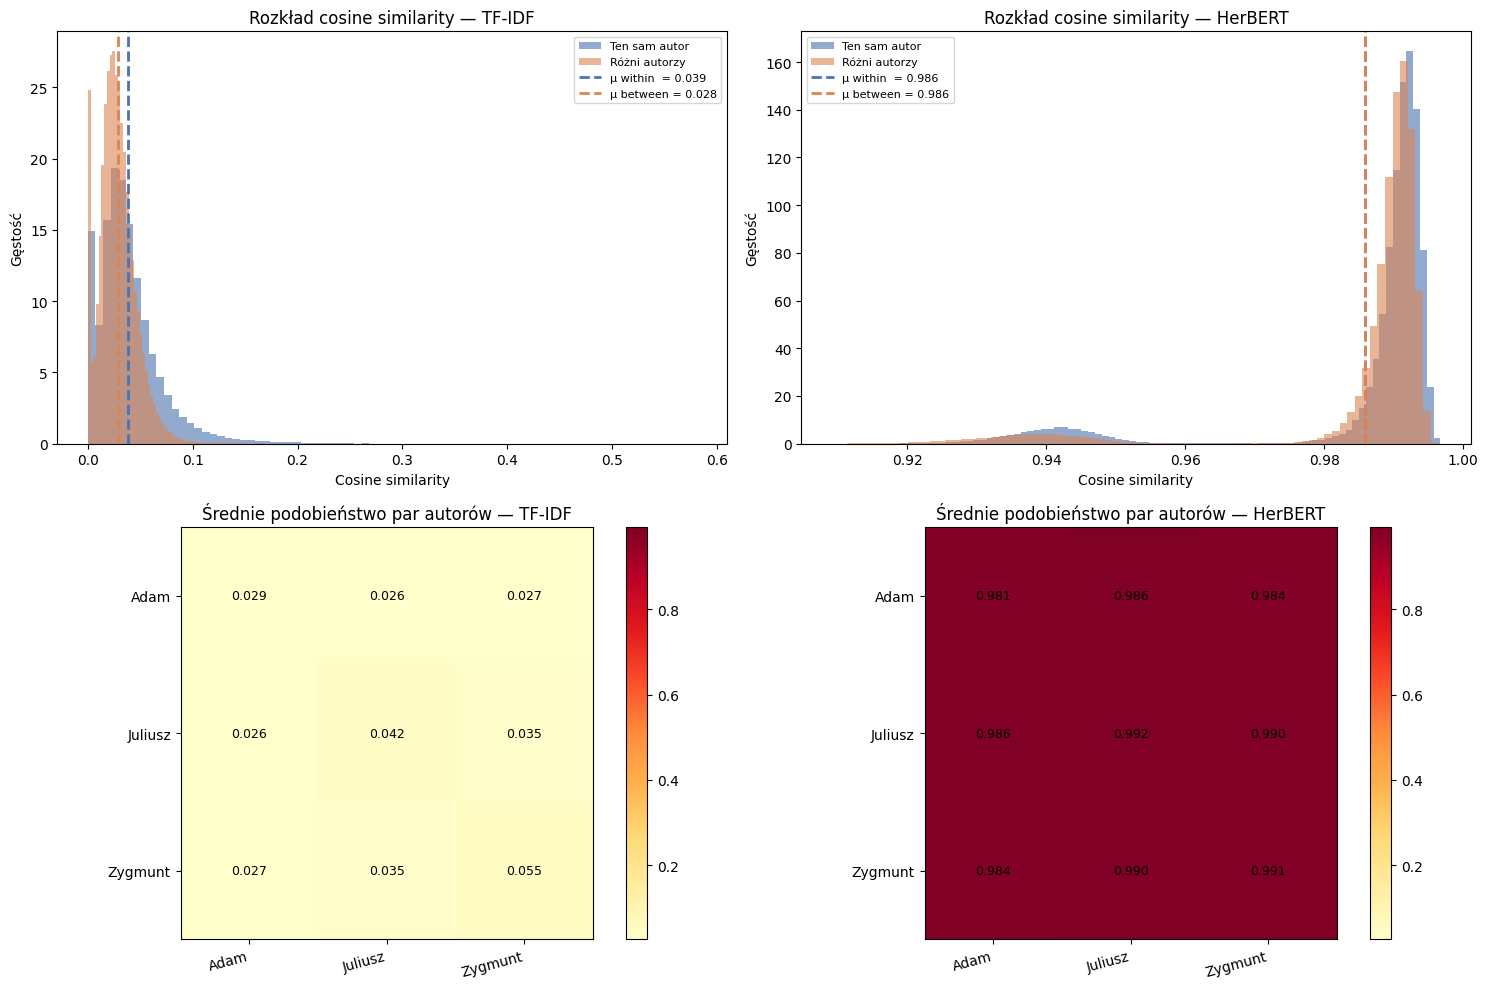


INTERPRETACJA WYNIKÓW

    Reprezentacja: TF-IDF
    within-author:   0.0386 ± 0.0300
    between-author:  0.0285 ± 0.0170
    Różnica (dyskryminowalność): +0.0101
    Mann-Whitney U=17848894840, p=0.0000e+00
    Effect size r=-0.192
    → Różnica within vs between: ISTOTNA STATYSTYCZNIE
    

    Reprezentacja: HerBERT
    within-author:   0.9859 ± 0.0156
    between-author:  0.9859 ± 0.0146
    Różnica (dyskryminowalność): -0.0000
    Mann-Whitney U=17495261184, p=0.0000e+00
    Effect size r=-0.168
    → Różnica within vs between: ISTOTNA STATYSTYCZNIE
    
Porównanie reprezentacji:
  within-author  TF-IDF vs HerBERT: p=0.0000e+00
  between-author TF-IDF vs HerBERT: p=0.0000e+00


In [10]:
print("Budowanie zbioru...")
df_chunks = build_chunk_dataset(df)
print(f"  Chunki: {len(df_chunks)} fragmentów z {df['title'].nunique()} tytułów")



tfidf = TfidfVectorizer(analyzer="word", ngram_range=(1, 1))
X_tfidf = tfidf.fit_transform(df_chunks["text"].values)  # sparse matrix (850 x vocab)


print("Generowanie embeddingów HerBERT")
X_herbert = get_herbert_embeddings(df_chunks["text"].tolist())
print(f"Kształt macierzy HerBERT: {X_herbert.shape}")   # (850, 768)


print("Obliczanie podobieństw TF-IDF...")
within_tfidf, between_tfidf = pairwise_similarities(
    X_tfidf, df_chunks["author"].values, is_sparse=True
)

print("Obliczanie podobieństw HerBERT...")
within_herbert, between_herbert = pairwise_similarities(
    X_herbert, df_chunks["author"].values, is_sparse=False
)

stats_per_repr = pd.DataFrame([
    run_stats(within_tfidf,    between_tfidf,    "TF-IDF"),
    run_stats(within_herbert,  between_herbert,  "HerBERT"),
])


print("\n=== Podobieństwo within vs between (dla każdej reprezentacji) ===")
print(stats_per_repr.to_string(index=False))


# Test: czy within-author różni się między reprezentacjami?
u_w, p_w = mannwhitneyu(within_tfidf,  within_herbert,  alternative="two-sided")
u_b, p_b = mannwhitneyu(between_tfidf, between_herbert, alternative="two-sided")

print("\n=== Porównanie reprezentacji (TF-IDF vs HerBERT) ===")
print(f"within-author:  U={u_w:.0f}, p={p_w:.4e}")
print(f"between-author: U={u_b:.0f}, p={p_b:.4e}")
authors = df_chunks["author"].unique()

pair_tfidf   = mean_pairwise_per_author_pair(X_tfidf,   df_chunks["author"].values,authors, is_sparse=True)
pair_herbert = mean_pairwise_per_author_pair(X_herbert, df_chunks["author"].values, authors,is_sparse=False)

short = {a: a.split("_")[0] for a in authors}

mat_tfidf   = pairs_to_matrix(pair_tfidf,   authors)
mat_herbert = pairs_to_matrix(pair_herbert, authors)
xlabels     = [short[a] for a in authors]

plot_results(
    within_tfidf,
    between_tfidf,
    within_herbert,
    between_herbert,
    mat_tfidf,
    mat_herbert,
    authors,
    xlabels,
    stats_per_repr,
    p_w,
    p_b,
)


### TF-IDF — działa, ale słabo

TF-IDF pokazuje statystycznie istotną, ale małą różnicę między tekstami tego samego i różnych autorów:

### HerBERT — całkowite załamanie dyskryminowalności

HerBERT był pretrenowany na surowym tekście polskim. Nasze chunki są po lematyzacji + usunięciu stop words — model dostaje ciągi form podstawowych bez fleksji, bez spójników, bez naturalnej składni. To jest inny rozkład tokenów niż widział podczas treningu, co powoduje kolaps embeddingów do jednego obszaru przestrzeni.


H₀ należy odrzucić — reprezentacja istotnie zmienia rozkład podobieństw (p ≪ 0.05 dla porównania TF-IDF vs HerBERT). Ale kierunek zaskakuje: TF-IDF okazuje się lepszy od kontekstowego modelu transformerowego.


# Pytanie 3

In [7]:
from pytania_badawcze.pytanie_3.preprocessing import build_feature_dataset
from pytania_badawcze.pytanie_3.evaluation import evaluate_feature_set, get_feature_importance
from pytania_badawcze.pytanie_3.plot import plot_result

Budowanie datasetu cech (spacy, ~3-7 min)...
  Spacy: 0/213 wierszy...
  Spacy: 10/213 wierszy...
  Spacy: 20/213 wierszy...
  Spacy: 30/213 wierszy...
  Spacy: 40/213 wierszy...
  Spacy: 50/213 wierszy...
  Spacy: 60/213 wierszy...
  Spacy: 70/213 wierszy...
  Spacy: 80/213 wierszy...
  Spacy: 90/213 wierszy...
  Spacy: 100/213 wierszy...
  Spacy: 110/213 wierszy...
  Spacy: 120/213 wierszy...
  Spacy: 130/213 wierszy...
  Spacy: 140/213 wierszy...
  Spacy: 150/213 wierszy...
  Spacy: 160/213 wierszy...
  Spacy: 170/213 wierszy...
  Spacy: 180/213 wierszy...
  Spacy: 190/213 wierszy...
  Spacy: 200/213 wierszy...
  Spacy: 210/213 wierszy...
Gotowe: 1477 fragmentów, 47 kolumn
Cechy leksykalne: 28
Cechy składniowe: 16

Klasyfikacja — cechy leksykalne...
Klasyfikacja — cechy składniowe...

=== Wyniki klasyfikacji ===
    zestaw  f1_mean   f1_std  acc_mean  acc_std
Leksykalne 0.283308 0.174384  0.321855 0.155636
Składniowe 0.265891 0.169530  0.326763 0.156650

=== Testy statystyczne (paro

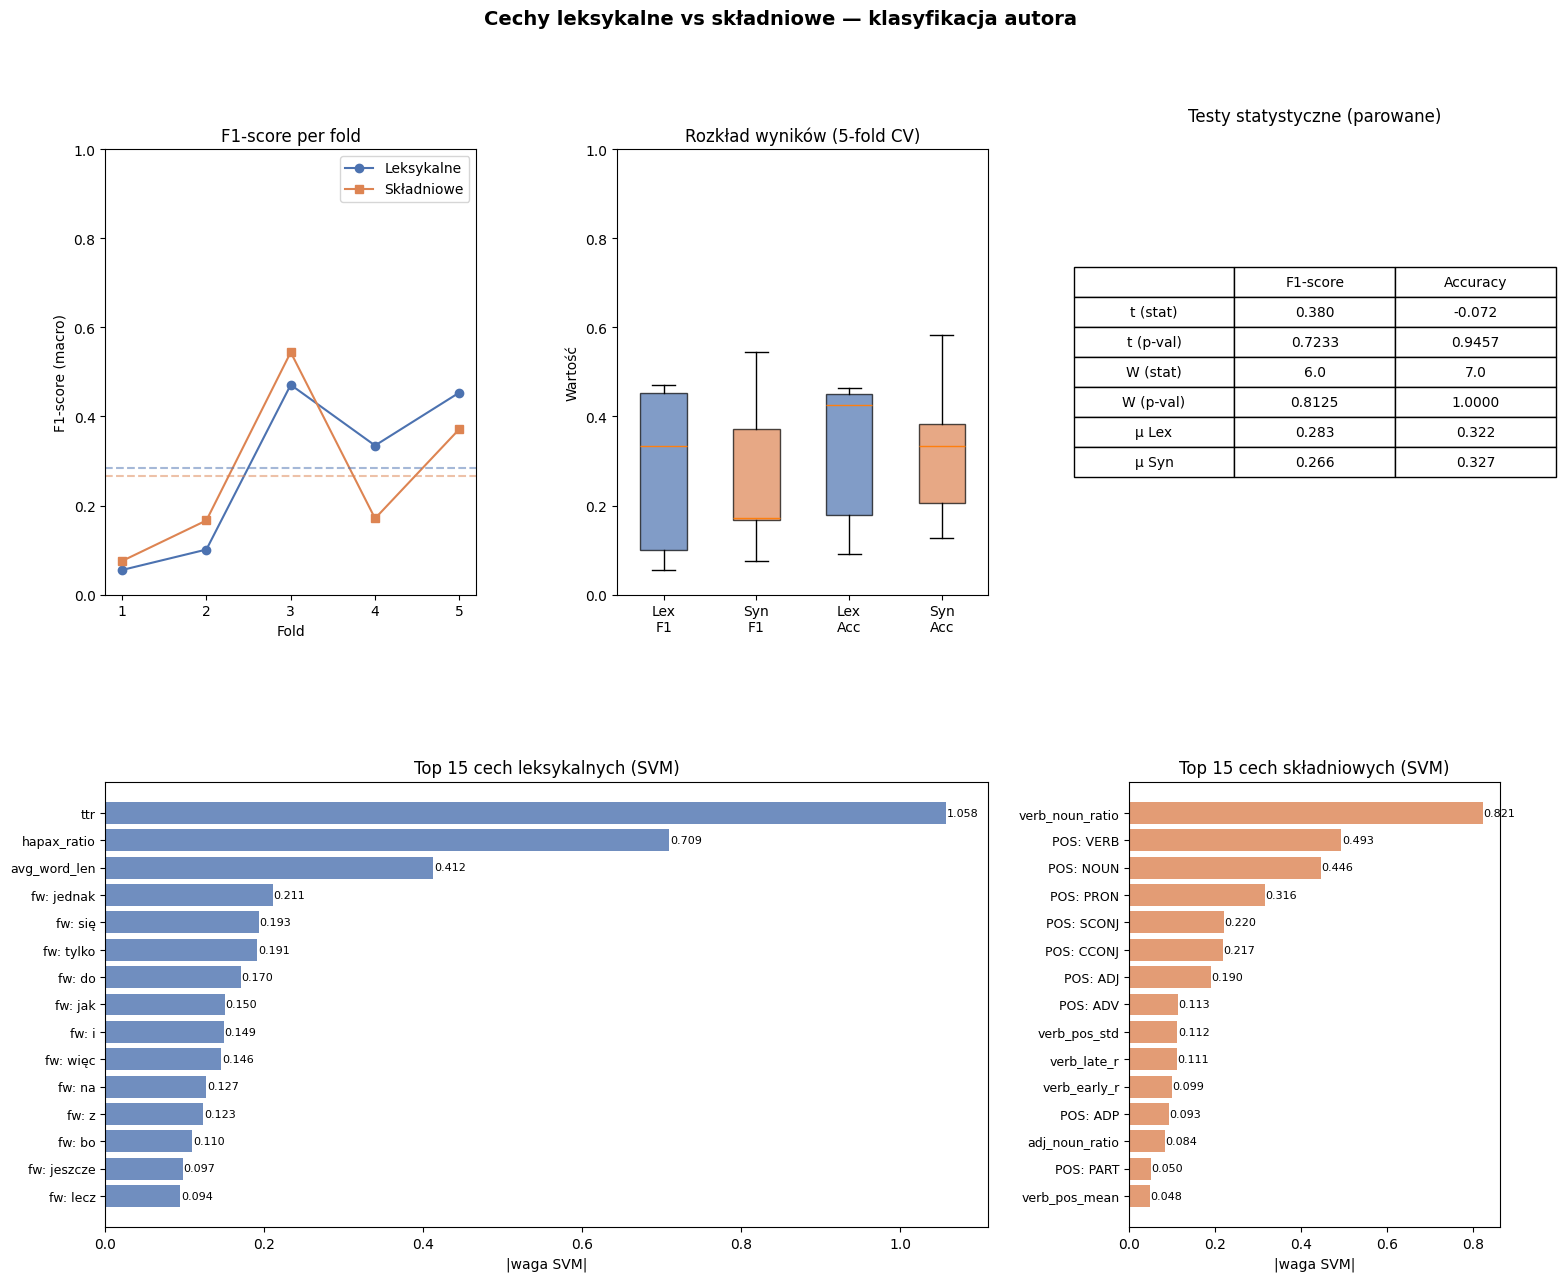

In [8]:

import numpy as np
import pandas as pd


import spacy
from scipy.stats import ttest_rel, wilcoxon

nlp = spacy.load("pl_core_news_sm")   # pełny pipeline: tagger + morph



print("Budowanie datasetu cech")
df_feats = build_feature_dataset(df)
print(f"Gotowe: {len(df_feats)} fragmentów, {df_feats.shape[1]} kolumn")

# Podział kolumn na grupy
lex_cols = [c for c in df_feats.columns if c.startswith("lex_")]
syn_cols = [c for c in df_feats.columns if c.startswith("syn_")]

print(f"Cechy leksykalne: {len(lex_cols)}")
print(f"Cechy składniowe: {len(syn_cols)}")


N_SPLITS = 5

print("\nKlasyfikacja — cechy leksykalne...")
f1_lex, acc_lex, splits = evaluate_feature_set(df_feats, lex_cols, N_SPLITS)

print("Klasyfikacja — cechy składniowe...")
f1_syn, acc_syn, _      = evaluate_feature_set(df_feats, syn_cols, N_SPLITS)


# t-test Studenta (parowany)
t_stat_f1,  t_p_f1  = ttest_rel(f1_lex,  f1_syn)
t_stat_acc, t_p_acc = ttest_rel(acc_lex, acc_syn)

# Wilcoxon (nieparametryczny, parowany)
try:
    w_stat_f1,  w_p_f1  = wilcoxon(f1_lex,  f1_syn)
    w_stat_acc, w_p_acc = wilcoxon(acc_lex, acc_syn)
except Exception:
    w_stat_f1 = w_p_f1 = w_stat_acc = w_p_acc = np.nan


summary = pd.DataFrame({
    "zestaw":     ["Leksykalne", "Składniowe"],
    "f1_mean":    [np.mean(f1_lex),  np.mean(f1_syn)],
    "f1_std":     [np.std(f1_lex),   np.std(f1_syn)],
    "acc_mean":   [np.mean(acc_lex), np.mean(acc_syn)],
    "acc_std":    [np.std(acc_lex),  np.std(acc_syn)],
})

stats_summary = pd.DataFrame({
    "metryka":        ["F1-score",    "Accuracy"],
    "t_stat":         [t_stat_f1,     t_stat_acc],
    "t_pvalue":       [t_p_f1,        t_p_acc],
    "wilcoxon_stat":  [w_stat_f1,     w_stat_acc],
    "wilcoxon_pval":  [w_p_f1,        w_p_acc],
})

print("\n=== Wyniki klasyfikacji ===")
print(summary.to_string(index=False))
print("\n=== Testy statystyczne (parowane) ===")
print(stats_summary.to_string(index=False))


imp_lex = get_feature_importance(df_feats, lex_cols)
imp_syn = get_feature_importance(df_feats, syn_cols)

TOP_N = 15


plot_result(
    f1_lex,
    f1_syn,
    acc_lex,
    acc_syn,
    t_stat_f1,
    t_stat_acc,
    t_p_f1,
    t_p_acc,
    w_stat_f1,
    w_stat_acc,
    w_p_f1,
    w_p_acc,
    imp_lex,
    imp_syn,
    TOP_N,
    N_SPLITS,
)




Oba testy dają p-wartości powyżej α=0.05 dla obu metryk.
Brak podstaw do odrzucenia H₀ — typ cech (leksykalne vs składniowe) nie wpływa istotnie na skuteczność klasyfikacji autora.

Oba zestawy działają słabo. Wyniki F1 ~0.27–0.28 są bliskie losowemu zgadywaniu dla 3 klas.

## Problemy
1. Lemmatyzacja vs cechy leksykalne


2. SpaCy współczesne teksty vs tesksy 19 wieku